# Assignment 5 — Clustering and Initialization
## k-means vs k-means++: The Advantages of Careful Seeding

**Course:** Statistical Methods for Machine Learning — A.Y. 2025/26  
**Instructor:** Nicolò Cesa-Bianchi, Università degli Studi di Milano  
**Student name:** Srishti Kansra — **Student ID:** 49483A

---

> *"I declare that this material, which I now submit for assessment, is entirely my own work and has not been taken from the work of others, save and to the extent that such work has been cited and acknowledged within the text of my work. I understand that plagiarism, collusion, and copying are grave and serious offences in the university and accept the penalties that would be imposed should I engage in plagiarism, collusion or copying. This assignment, or any part of it, has not been previously submitted by me or any other person for assessment on this or any other course of study."*

## Executive Summary

This project implements and compares two initialization strategies for the k-means clustering
algorithm: **uniform random (Forgy)** seeding and **k-means++** (Arthur & Vassilvitskii, SODA
2007), across a synthetic well-separated dataset, a synthetic overlapping dataset, and a
real-world high-dimensional dataset (scikit-learn Digits, 64 features, 10 classes).

Every algorithm and evaluation metric is implemented **from scratch** using only NumPy.
scikit-learn is used exclusively to generate or load the raw datasets.

The analysis covers:

1. **Theory** — the k-means objective, the two initialization strategies, and their theoretical
   guarantees
2. **Algorithms** — fully-commented from-scratch implementations of Forgy init, k-means++ D²
   seeding, and Lloyd's optimization loop
3. **Metrics** — inertia (internal), Adjusted Rand Index and NMI (external, from scratch),
   and a stability metric; convergence curves for each experiment
4. **Experiment 1** — well-separated clusters: the regime where k-means++ excels
5. **Experiment 2** — overlapping clusters: an extension probing the harder regime
6. **Experiment 3** — varying k: empirical verification of the O(log k) theoretical guarantee
7. **Experiment 4** — real-world high-dimensional data: the regime where the advantage
   disappears
8. **Cross-dataset comparison** — external quality (ARI, NMI) side-by-side

> **Key finding:** k-means++ is not unconditionally better. It wins decisively on
> well-separated low-dimensional data (60.4% lower inertia, ARI 0.97 vs 0.83), provides
> stability but not quality gains on overlapping data, and offers no advantage — in fact a
> small disadvantage — on high-dimensional real data where distance concentration defeats the
> D² heuristic. The advantage grows with k, matching the O(log k) theory.

## 0. Setup and global configuration

All tunable parameters live in a single `CFG` dictionary so the entire notebook is
reproducible by editing one cell. The color scheme (`COLORS`) and display names (`LABELS`)
are defined once and reused in all figures to keep comparisons visually consistent.

In [23]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs, load_digits   # ONLY used to load/generate data

# ── Global configuration ─────────────────────────────────────────────────────
CFG = {
    'random_state': 42,    # master seed — every stochastic step uses this
    'n_trials':     50,    # independent restarts per (dataset, init) setting
    'max_iter':     300,   # Lloyd iteration cap (rarely reached)
    'tol':          1e-4,  # convergence: max center shift below this → stop
}

# ── Consistent visual identity for the two methods ───────────────────────────
COLORS = {'random': '#E07B54', 'kmeans++': '#4A90D9'}
LABELS = {'random': 'k-means (random init)', 'kmeans++': 'k-means++'}

plt.rcParams.update({
    'font.family': 'serif', 'font.size': 11,
    'axes.spines.top': False, 'axes.spines.right': False,
    'figure.dpi': 130,
})

os.makedirs('figures', exist_ok=True)
print('Setup complete. CFG =', CFG)

Setup complete. CFG = {'random_state': 42, 'n_trials': 50, 'max_iter': 300, 'tol': 0.0001}


## 1. Theoretical background

### 1.1 The k-means objective

Given $n$ data points $x_1, \ldots, x_n \in \mathbb{R}^d$ and a target number of clusters
$k$, k-means seeks $k$ **center** vectors $c_1, \ldots, c_k$ that minimize the
**within-cluster sum of squared distances** (also called *inertia* or the k-means objective):

$$\phi(c_1,\ldots,c_k) = \sum_{i=1}^{n} \min_{j \in \{1,\ldots,k\}} \| x_i - c_j \|^2$$

This objective is **non-convex**: it has many local minima, and the solution Lloyd's algorithm
converges to depends heavily on the initial centers. Two runs on the same dataset with different
starting points can produce very different partitions with very different objective values.
Initialization is therefore not a minor implementation detail — it is a core algorithmic choice
that directly determines solution quality.

### 1.2 Lloyd's algorithm

Lloyd's algorithm alternates two steps until convergence:

- **Assignment step:** assign each $x_i$ to the nearest center:
  $\text{label}(x_i) = \arg\min_j \|x_i - c_j\|^2$
- **Update step:** set each center to the mean of its assigned points:
  $c_j \leftarrow \frac{1}{|C_j|} \sum_{x \in C_j} x$

Each step can only decrease $\phi$, so the algorithm always converges to a *local* minimum in
a finite number of steps. The problem is that the local minimum reached depends entirely on
where we start.

### 1.3 Initialization strategies

**Random (Forgy) initialization** selects $k$ data points uniformly at random as the initial
centers. It is simple and $O(k)$ but offers no guarantee on solution quality: with non-trivial
probability, two initial centers land in the same true cluster, causing a bad local minimum.

**k-means++ initialization** (Arthur & Vassilvitskii, SODA 2007) chooses centers
sequentially:
1. Pick the first center $c_1$ uniformly at random from $X$.
2. For each subsequent center $c_\ell$, sample a point $x$ with probability proportional to
   $D(x)^2 = \min_{j < \ell} \|x - c_j\|^2$ — the squared distance to the nearest already-
   chosen center.

This *$D^2$ weighting* biases the seeding toward points far from all existing centers, making
it much less likely that two seeds land in the same cluster. The seeding step costs $O(knd)$
but is completely dominated by Lloyd's iterations in practice.

### 1.4 Theoretical guarantee

The key result of the paper is:

> **Theorem (Arthur & Vassilvitskii 2007).**  
> Let $\phi^*$ be the optimal k-means cost. The expected cost of k-means++ initialization
> satisfies:
> $$\mathbb{E}[\phi_0] \leq 8(\ln k + 2) \cdot \phi^*$$

This is an **O(log k)-competitive** guarantee: k-means++ can never start more than a
logarithmic factor worse than optimal, regardless of the data. Random initialization has no
such guarantee — it can start arbitrarily far from $\phi^*$. The guarantee holds before any
Lloyd iterations; after a full run to convergence, k-means++ typically achieves much better
results in practice than the bound suggests.

The O(log k) factor also predicts that the *advantage of k-means++ grows with k* — which we
verify empirically in Experiment 3.

## 2. Algorithms (implemented from scratch)

This section implements the full k-means pipeline in NumPy without any machine-learning
library. The code is organized in three subsections that mirror the theory above:

- **2.1 Geometric helpers** — computing the objective and performing the two Lloyd steps
- **2.2 Initialization strategies** — the only part that differs between the two methods
- **2.3 Lloyd's loop** — the shared optimization engine

### 2.1 Geometric helpers

In [24]:
def compute_inertia(X, labels, centers):
    """
    Compute the k-means objective: sum of squared distances of each point
    to its assigned center.

    Parameters
    ----------
    X       : (n, d) array of data points
    labels  : (n,)   integer cluster assignment for each point
    centers : (k, d) cluster centers

    Returns
    -------
    float  — the total within-cluster sum of squared distances (lower = tighter clusters)
    """
    inertia = 0.0
    for j in range(len(centers)):
        mask = labels == j
        if np.any(mask):
            # Squared Euclidean distance from each point in cluster j to center j
            inertia += np.sum((X[mask] - centers[j]) ** 2)
    return inertia


def assign_labels(X, centers):
    """
    Assignment step: label each point with the index of its nearest center.

    Uses vectorized broadcasting to avoid an explicit loop over points.
    Shape trace:
      X          : (n, d)
      centers    : (k, d)
      diffs      : (n, k, d)  —  X[:, newaxis, :] - centers[newaxis, :, :]
      dists_sq   : (n, k)     —  sum of squared diffs over axis 2
      labels     : (n,)       —  argmin over axis 1

    Parameters
    ----------
    X       : (n, d) array
    centers : (k, d) array

    Returns
    -------
    (n,) integer array of cluster indices
    """
    diffs    = X[:, np.newaxis, :] - centers[np.newaxis, :, :]   # (n, k, d)
    dists_sq = np.sum(diffs ** 2, axis=2)                        # (n, k)
    return np.argmin(dists_sq, axis=1)                          # (n,)


def update_centers(X, labels, k, rng):
    """
    Update step: set each center to the mean of its assigned points.

    Empty cluster handling: if a cluster ends up with no assigned points
    (rare but possible, especially for large k), we re-seed it with a
    randomly chosen data point. Critically, we draw from the SAME seeded
    generator `rng` used throughout the run, so a given `random_state`
    reproduces every step of the run exactly — including any empty-cluster
    recoveries.

    Using numpy's global RNG here (np.random.choice) instead would
    introduce hidden non-reproducibility: two runs with the same seed
    could diverge if they hit different empty-cluster events.

    Parameters
    ----------
    X      : (n, d) data array
    labels : (n,)   current cluster assignment
    k      : int    number of clusters
    rng    : numpy Generator  (the seeded generator for this run)

    Returns
    -------
    (k, d) array of updated centers
    """
    d = X.shape[1]
    centers = np.zeros((k, d))
    for j in range(k):
        mask = labels == j
        if np.any(mask):
            centers[j] = X[mask].mean(axis=0)     # standard centroid update
        else:
            centers[j] = X[rng.integers(0, len(X))]  # reproducible empty-cluster fix
    return centers

### 2.2 Initialization strategies

The two methods below are **the only thing that differs** between the two algorithms we
compare. Everything else — the Lloyd loop, the metrics, the harness — is shared.

In [25]:
def init_random(X, k, rng):
    """
    Forgy (random) initialization: pick k distinct data points uniformly at random.

    This is $O(k)$ and simple, but offers no quality guarantee. Because seeds are
    drawn uniformly, with non-negligible probability two initial centers fall in the
    same true cluster, setting up a bad local minimum that Lloyd cannot escape.
    (The probability that all k seeds land in k distinct clusters is k!/k^k, which
    decays quickly as k grows.)

    Parameters
    ----------
    X   : (n, d) data array
    k   : int    number of centers
    rng : numpy Generator

    Returns
    -------
    (k, d) array of initial centers (copies of data points)
    """
    idx = rng.choice(len(X), size=k, replace=False)
    return X[idx].copy()


def init_kmeans_plus_plus(X, k, rng):
    """
    k-means++ D² seeding (Arthur & Vassilvitskii, SODA 2007).

    Algorithm:
      1. Choose the first center c₁ uniformly at random.
      2. For each subsequent center cₗ (l = 2, …, k):
         a. Compute D(x)² = min_{j<l} ||x - cⱼ||²  for every x in X.
            This is the squared distance from x to the nearest already-chosen center.
         b. Sample the next center from X with probability proportional to D(x)².
            Points far from all existing centers are sampled more often — this
            spreads the seeds and makes the bad-local-minimum scenario unlikely.

    Seeding cost: O(k · n · d) — negligible vs Lloyd's O(I · n · k · d).

    Parameters
    ----------
    X   : (n, d) data array
    k   : int    number of centers
    rng : numpy Generator

    Returns
    -------
    (k, d) array of initial centers
    """
    n = len(X)
    # Step 1: first center uniform at random
    centers = [X[rng.integers(0, n)].copy()]

    # Step 2: each subsequent center sampled with probability ∝ D(x)²
    for _ in range(k - 1):
        C     = np.array(centers)                                  # (c, d)
        diffs = X[:, np.newaxis, :] - C[np.newaxis, :, :]         # (n, c, d)
        D2    = np.sum(diffs ** 2, axis=2).min(axis=1)            # (n,) D(x)² to nearest center
        probs = D2 / D2.sum()                                     # normalize to a distribution
        centers.append(X[rng.choice(n, p=probs)].copy())

    return np.array(centers)   # (k, d)


# Registry: maps the string name used in CFG and experiment calls to the function.
# Adding a new initialization strategy only requires adding it here.
INITIALIZERS = {
    'random':   init_random,
    'kmeans++': init_kmeans_plus_plus,
}

### 2.3 Lloyd's algorithm

The shared optimization loop. The `init` parameter selects the initialization via `INITIALIZERS`,
so the loop itself is agnostic to the seeding strategy. The function returns the number of
iterations performed so we can study convergence speed as a second metric.

In [26]:
def kmeans(X, k, init='random', random_state=None,
           max_iter=CFG['max_iter'], tol=CFG['tol']):
    """
    Run k-means with a pluggable initialization strategy.

    Convergence criterion: the maximum L2 shift of any center between two
    successive iterations falls below `tol`. This is stricter than checking
    the objective change, because a center can move without the objective
    changing much (when only a few points are affected).

    Parameters
    ----------
    X            : (n, d) array of data points
    k            : int    number of clusters
    init         : str    'random' or 'kmeans++'  (must be in INITIALIZERS)
    random_state : int or None  — seed for the run's RNG
    max_iter     : int    maximum number of Lloyd iterations
    tol          : float  convergence threshold on max center shift

    Returns
    -------
    centers  : (k, d)  final cluster centers
    labels   : (n,)    final cluster assignment
    inertia  : float   final value of the k-means objective
    n_iter   : int     number of Lloyd iterations performed
    """
    # One generator drives the entire run (init + empty-cluster fallback)
    rng = np.random.default_rng(random_state)

    # --- Initialization ---------------------------------------------------
    centers = INITIALIZERS[init](X, k, rng)

    # --- Lloyd iterations -------------------------------------------------
    n_iter = 0
    for i in range(1, max_iter + 1):
        n_iter = i

        labels      = assign_labels(X, centers)        # E-step
        new_centers = update_centers(X, labels, k, rng) # M-step

        # Convergence check: max shift of any center
        shift = np.max(np.linalg.norm(new_centers - centers, axis=1))
        centers = new_centers

        if shift < tol:
            break   # converged

    # Final assignment and objective (may differ from last-iteration labels
    # if centers moved during the final iteration)
    labels  = assign_labels(X, centers)
    inertia = compute_inertia(X, labels, centers)
    return centers, labels, inertia, n_iter

print('All algorithm functions defined.')

All algorithm functions defined.


## 3. Evaluation metrics (from scratch)

### 3.1 Why inertia alone is not enough

The k-means objective $\phi$ is an **internal** criterion — it measures compactness without
reference to any ground truth. It has two important limitations:

1. **Incomparability across datasets.** A lower inertia on dataset A vs dataset B means
   nothing: inertia scales with the number of points, their spread, and the feature dimension.
2. **Decoupled from true clusters.** A lower inertia does not imply a partition closer to the
   true grouping. In high dimensions especially, the two can completely disagree.

Because every dataset in this project has ground-truth labels, we measure two **external**
metrics that compare the predicted partition to the true one, without requiring any
cluster-to-class matching. We also add one **stability** metric that quantifies how
consistently a method avoids bad local minima.

### 3.2 Adjusted Rand Index (ARI)

The Rand Index counts concordant pairs: pairs of points that are either in the same cluster
*and* the same true class, or in different clusters *and* different true classes. The
**Adjusted** Rand Index corrects for agreement expected by chance, so that a random partition
scores ≈ 0 and a perfect partition scores 1.0. It can be negative if the partition is worse
than random.

$$\text{ARI} = \frac{\sum_{ij} \binom{n_{ij}}{2} - \frac{\left(\sum_i \binom{a_i}{2}\right)\left(\sum_j \binom{b_j}{2}\right)}{\binom{n}{2}}}{\frac{1}{2}\left[\sum_i \binom{a_i}{2} + \sum_j \binom{b_j}{2}\right] - \frac{\left(\sum_i \binom{a_i}{2}\right)\left(\sum_j \binom{b_j}{2}\right)}{\binom{n}{2}}}$$

where $n_{ij}$ is the contingency table, $a_i = \sum_j n_{ij}$ and $b_j = \sum_i n_{ij}$.

### 3.3 Normalized Mutual Information (NMI)

NMI measures the shared information between the predicted clusters $U$ and the true classes $V$:

$$\text{NMI}(U, V) = \frac{I(U; V)}{\frac{1}{2}[H(U) + H(V)]}$$

where $I$ is mutual information and $H$ is entropy, both computed from the empirical
distribution of the contingency table. NMI = 1 for a perfect partition, NMI = 0 for
independent labelings. The arithmetic-mean normalization makes it symmetric.

### 3.4 Near-optimal fraction (stability)

A direct stability metric: the fraction of restarts whose inertia lands within
$(1 + \tau)$ of the best inertia found across all restarts (we use $\tau = 0.01$, i.e., 1%).
A method scoring 88% means it consistently finds a near-optimal solution; one scoring 42%
fails to do so in more than half of runs. This is a more interpretable stability measure
than the coefficient of variation because it is directly tied to solution quality.

In [27]:
def contingency(labels_true, labels_pred):
    """
    Compute the contingency table n_ij:
      rows    = true classes (re-indexed 0, 1, ...)
      columns = predicted clusters (re-indexed 0, 1, ...)
      n_ij   = number of points with true class i AND predicted cluster j

    Using np.add.at for scatter-accumulation avoids two nested loops.
    """
    t = np.unique(labels_true, return_inverse=True)[1]    # re-index true labels to 0..C-1
    p = np.unique(labels_pred, return_inverse=True)[1]    # re-index pred labels to 0..K-1
    C = np.zeros((t.max() + 1, p.max() + 1), dtype=np.int64)
    np.add.at(C, (t, p), 1)
    return C


def adjusted_rand_index(labels_true, labels_pred):
    """
    Adjusted Rand Index (Hubert & Arabie, 1985).

    Implemented directly from the combinatorial formula using C(n, 2) = n(n-1)/2.
    Returns 1.0 for a perfect partition, ≈ 0 for chance agreement.
    """
    C = contingency(labels_true, labels_pred)
    n = C.sum()
    comb2 = lambda x: x * (x - 1) / 2.0          # C(x, 2), vectorized-friendly

    sum_ij   = comb2(C).sum()                     # sum over all cells
    a        = comb2(C.sum(axis=1)).sum()          # sum over true-class marginals
    b        = comb2(C.sum(axis=0)).sum()          # sum over cluster marginals
    expected = a * b / comb2(n)                   # expected index under random model
    max_idx  = 0.5 * (a + b)                      # maximum possible index

    if max_idx == expected:
        return 1.0                                # degenerate case: trivially perfect
    return (sum_ij - expected) / (max_idx - expected)


def normalized_mutual_info(labels_true, labels_pred):
    """
    Normalized Mutual Information with arithmetic-mean normalization.

    I(U;V) / ((H(U) + H(V)) / 2)

    All quantities are derived from the empirical joint distribution p_ij = n_ij / n.
    The nz (nonzero) mask avoids 0 * log(0) = NaN.
    """
    C   = contingency(labels_true, labels_pred).astype(float)
    n   = C.sum()
    pij = C / n                                    # joint distribution P(U=i, V=j)
    pi  = pij.sum(axis=1, keepdims=True)            # marginal P(U=i)
    pj  = pij.sum(axis=0, keepdims=True)            # marginal P(V=j)

    nz  = pij > 0
    mi  = np.sum(pij[nz] * np.log(pij[nz] / (pi @ pj)[nz]))   # I(U; V)
    hi  = -np.sum(pi[pi > 0] * np.log(pi[pi > 0]))             # H(U)
    hj  = -np.sum(pj[pj > 0] * np.log(pj[pj > 0]))             # H(V)

    denom = 0.5 * (hi + hj)
    return mi / denom if denom > 0 else 1.0


def near_optimal_fraction(inertia_array, tau=0.01):
    """
    Fraction of restarts landing within (1 + tau) of the best inertia found.

    Parameters
    ----------
    inertia_array : (n_trials,) array of inertia values
    tau           : float  tolerance (default 0.01 = 1%)

    Returns
    -------
    float in [0, 1]
    """
    best = inertia_array.min()
    return np.mean(inertia_array <= best * (1 + tau))

print('All metric functions defined.')

All metric functions defined.


## 4. Experiment harness

The harness runs many independent restarts and collects all metrics into arrays, so each
experiment in Section 6 can focus on interpretation rather than bookkeeping.

### Design choices

**Paired seeds.** Both initializations are evaluated on the *same* sequence of random seeds
(drawn once from the master RNG). This means each trial index $t$ corresponds to exactly the
same starting randomness for both methods — the only difference between the two runs at trial
$t$ is the initialization strategy. Any measured difference in outcomes is therefore
attributable to initialization, not to luck in the seed draw.

**Seeded generator chain.** `run_trials` uses `CFG['random_state']` to generate the per-trial
seeds. This chain is fully reproducible: changing `CFG['random_state']` changes all seeds
uniformly, while keeping it fixed makes every result reproducible across machines and Python
versions.

In [28]:
def run_trials(X, k, init, y_true=None,
               n_trials=CFG['n_trials'], random_state=CFG['random_state']):
    """
    Run k-means with a given initialization strategy for n_trials independent restarts.

    Each restart gets its own seed drawn from a master RNG seeded with `random_state`,
    so the full trial sequence is reproducible.

    Parameters
    ----------
    X            : (n, d) data array
    k            : int    number of clusters
    init         : str    initialization strategy ('random' or 'kmeans++')
    y_true       : (n,) array or None  — if provided, ARI and NMI are computed
    n_trials     : int    number of restarts
    random_state : int    seed for the master RNG

    Returns
    -------
    dict with keys:
      'inertia'  : (n_trials,) float array
      'iters'    : (n_trials,) int array
      'ari'      : (n_trials,) float array  [only if y_true is not None]
      'nmi'      : (n_trials,) float array  [only if y_true is not None]
    """
    rng   = np.random.default_rng(random_state)
    seeds = rng.integers(0, 10_000, size=n_trials)   # per-trial seeds

    inertia, iters, ari, nmi = [], [], [], []
    for s in seeds:
        _, labels, J, it = kmeans(X, k, init=init, random_state=int(s))
        inertia.append(J)
        iters.append(it)
        if y_true is not None:
            ari.append(adjusted_rand_index(y_true, labels))
            nmi.append(normalized_mutual_info(y_true, labels))

    out = {'inertia': np.array(inertia), 'iters': np.array(iters)}
    if y_true is not None:
        out['ari'] = np.array(ari)
        out['nmi'] = np.array(nmi)
    return out


def evaluate_initializations(X, k, y_true=None):
    """
    Run BOTH initialization strategies on one dataset with PAIRED seeds.

    Parameters
    ----------
    X      : (n, d) data array
    k      : int    number of clusters
    y_true : (n,) array or None

    Returns
    -------
    dict {'random': {...}, 'kmeans++': {...}}
    Each value is a result dict from run_trials.
    """
    return {init: run_trials(X, k, init, y_true) for init in INITIALIZERS}


def summarize(name, results):
    """Print a compact aligned summary of an evaluate_initializations() result."""
    print(f'\n{name}')
    print(f'  {"Method":<12} {"Inertia (mean±std)":>22}  {"iters":>5}  {"near-opt":>8}', end='')
    if 'ari' in next(iter(results.values())):
        print(f'  {"ARI":>6}  {"NMI":>6}', end='')
    print()
    print('  ' + '-' * 75)
    for init, r in results.items():
        line = (f'  {init:<12} '
                f'{r["inertia"].mean():>10.1f} ± {r["inertia"].std():<8.1f}'
                f'{r["iters"].mean():>6.2f}  '
                f'{near_optimal_fraction(r["inertia"]):>8.0%}')
        if 'ari' in r:
            line += f'  {r["ari"].mean():>6.3f}  {r["nmi"].mean():>6.3f}'
        print(line)

print('Harness functions defined.')

Harness functions defined.


## 5. Visualization helpers

All Matplotlib code is encapsulated in reusable helpers so the experiment cells in Section 6
focus on interpretation, not plotting. Every helper saves a PDF to `figures/` for the report.

In [29]:
def _save(fig, fname):
    """Tight-layout, save to figures/<fname>.pdf, then show inline."""
    fig.tight_layout()
    fig.savefig(f'figures/{fname}.pdf', bbox_inches='tight')
    plt.show()


def _boxstrip(ax, arrays, colors, jitter_seed, title, ylabel='Inertia'):
    """Box plot + jittered strip of raw trial values (shared sub-helper)."""
    bp = ax.boxplot(arrays, patch_artist=True, widths=0.4,
                    medianprops=dict(color='black', linewidth=2))
    for patch, c in zip(bp['boxes'], colors):
        patch.set_facecolor(c); patch.set_alpha(0.7)
    rng = np.random.default_rng(jitter_seed)
    for i, (vals, c) in enumerate(zip(arrays, colors), start=1):
        jitter = rng.uniform(-0.12, 0.12, len(vals))
        ax.scatter(np.full(len(vals), i) + jitter, vals,
                   color=c, alpha=0.35, s=16, zorder=3)
    ax.set_xticks([1, 2])
    ax.set_xticklabels([LABELS['random'], LABELS['kmeans++']])
    ax.set_ylabel(ylabel)
    ax.set_title(title)


def _ecdf(ax, arrays, colors, labels, title, tau=0.01, ylabel=None):
    """Empirical CDF of inertia: fraction of restarts at or below each value.
    A vertical dotted line marks the (1+tau)*best near-optimal threshold, so the
    near-optimal fraction is read directly as where each curve crosses it."""
    best = min(a.min() for a in arrays)
    for vals, c, lab in zip(arrays, colors, labels):
        v = np.sort(vals)
        y = np.arange(1, len(v) + 1) / len(v)
        ax.step(v, y, where='post', color=c, linewidth=2, label=lab)
        ax.scatter(v, y, color=c, s=12, alpha=0.45, zorder=3)
    ax.axvline(best * (1 + tau), color='gray', linestyle=':', linewidth=1.2,
               label=f'{int(tau*100)}% near-optimal threshold')
    ax.set_xlabel('Inertia')
    ax.set_ylabel(ylabel or 'Fraction of restarts \u2264 inertia')
    ax.set_title(title)
    ax.legend(fontsize=9)


def plot_inertia_panel(results, title, fname, jitter_seed=0):
    """
    Two-panel figure:
      Left  — box + strip plot of raw inertia across n_trials restarts
              (box shows quartiles; jittered points show every individual run,
              making the bimodal good-run / bad-run structure visible)
      Right — coefficient of variation bar chart (std/mean, %)
    """
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    _boxstrip(
        axes[0],
        [results['random']['inertia'], results['kmeans++']['inertia']],
        [COLORS['random'], COLORS['kmeans++']],
        jitter_seed,
        f"Inertia over {CFG['n_trials']} restarts"
    )
    cvs = [results[m]['inertia'].std() / results[m]['inertia'].mean() * 100
           for m in ('random', 'kmeans++')]
    bars = axes[1].bar(
        [LABELS[m] for m in ('random', 'kmeans++')], cvs,
        color=[COLORS['random'], COLORS['kmeans++']], alpha=0.8, width=0.4
    )
    axes[1].bar_label(bars, fmt='%.2f%%', padding=3)
    axes[1].set_ylabel('Coefficient of Variation (%)')
    axes[1].set_title('Run-to-run variability (lower = more stable)')
    axes[1].set_ylim(0, max(cvs) * 1.45)
    fig.suptitle(title, fontsize=13, y=1.02)
    _save(fig, fname)


def plot_convergence(results, title, fname):
    """Box + strip plot of Lloyd iterations-to-convergence."""
    fig, ax = plt.subplots(figsize=(6, 4.5))
    _boxstrip(
        ax,
        [results['random']['iters'], results['kmeans++']['iters']],
        [COLORS['random'], COLORS['kmeans++']],
        jitter_seed=99,
        title=title,
        ylabel='Lloyd iterations to convergence'
    )
    _save(fig, fname)


def plot_convergence_curve(curves_dict, title, fname):
    """
    Line plot of the k-means objective (inertia) per Lloyd iteration for a single
    representative run of each method. Tracking inertia directly shows Lloyd's
    monotone decrease of the objective and makes the seeding advantage visible at
    iteration 1 (better-placed initial centers start from a lower objective).
    """
    fig, ax = plt.subplots(figsize=(8, 4))
    for init, phis in curves_dict.items():
        ax.plot(range(1, len(phis) + 1), phis,
                marker='o', markersize=4, linewidth=1.8,
                color=COLORS[init], label=LABELS[init])
    ax.set_yscale('log')
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Inertia $\\phi$  (log scale)')
    ax.set_title(title)
    ax.legend()
    _save(fig, fname)


def plot_scatter_failure(X, k, fname):
    """
    Three scatter plots to illustrate the failure mode of random initialization:
      left   — the WORST random-init run (highest inertia across all restarts)
      center — a TYPICAL (median-inertia) random-init run
      right  — the BEST k-means++ run (lowest inertia)
    Black X markers indicate final cluster centers.
    """
    rng   = np.random.default_rng(CFG['random_state'])
    seeds = rng.integers(0, 10_000, size=CFG['n_trials'])
    runs_r = [kmeans(X, k, 'random',   random_state=int(s)) for s in seeds]
    runs_p = [kmeans(X, k, 'kmeans++', random_state=int(s)) for s in seeds]

    order_r = np.argsort([r[2] for r in runs_r])
    order_p = np.argsort([r[2] for r in runs_p])

    panels = [
        (runs_r[order_r[-1]],              'random init — WORST run',     COLORS['random']),
        (runs_r[order_r[len(order_r)//2]], 'random init — typical (med)', COLORS['random']),
        (runs_p[order_p[0]],               'k-means++ — BEST run',        COLORS['kmeans++']),
    ]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
    for ax, ((centers, labels, J, _), ttl, col) in zip(axes, panels):
        ax.scatter(X[:, 0], X[:, 1], c=labels, cmap='tab10',
                   s=15, alpha=0.6, linewidths=0)
        ax.scatter(centers[:, 0], centers[:, 1],
                   c='black', marker='X', s=150, zorder=5)
        ax.set_title(f'{ttl}\nInertia = {J:.0f}', color=col, fontweight='bold')
        ax.set_xlabel('Feature 1'); ax.set_ylabel('Feature 2')
    fig.suptitle('Failure mode of random init vs k-means++ on well-separated clusters', fontsize=13)
    _save(fig, fname)


def plot_k_sweep(X, k_values, fname):
    """
    Sweep k from k_values[0] to k_values[-1]:
      Left  — mean ± std inertia for each method at each k
      Right — ratio of random/k-means++ mean inertia vs k
              (theory predicts this grows as O(log k))
    """
    mean_r, std_r, mean_p, std_p, ratio = [], [], [], [], []
    for k in k_values:
        ir = run_trials(X, k, 'random')['inertia']
        ip = run_trials(X, k, 'kmeans++')['inertia']
        mean_r.append(ir.mean()); std_r.append(ir.std())
        mean_p.append(ip.mean()); std_p.append(ip.std())
        ratio.append(ir.mean() / ip.mean())
        print(f'  k={k:2d}  random={ir.mean():7.0f}  kmeans++={ip.mean():7.0f}  '
              f'ratio={ratio[-1]:.3f}  (log k factor = {np.log(k):.2f})')
    mean_r, std_r = np.array(mean_r), np.array(std_r)
    mean_p, std_p = np.array(mean_p), np.array(std_p)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    for m, mean, std in [('random', mean_r, std_r), ('kmeans++', mean_p, std_p)]:
        axes[0].plot(k_values, mean, marker='o', color=COLORS[m],
                     label=LABELS[m], linewidth=2)
        axes[0].fill_between(k_values, mean - std, mean + std,
                             color=COLORS[m], alpha=0.15)
    axes[0].set_xlabel('Number of clusters k')
    axes[0].set_ylabel(f'Mean inertia ± std  ({CFG["n_trials"]} trials)')
    axes[0].set_title('Mean inertia vs k')
    axes[0].legend()

    axes[1].plot(k_values, ratio, marker='s', color='#5B8C5A', linewidth=2,
                 label='mean inertia  random / k-means++')
    axes[1].axhline(1.0, color='gray', ls='--', lw=1)
    axes[1].set_xlabel('Number of clusters k')
    axes[1].set_ylabel('Inertia ratio (random / k-means++)')
    axes[1].set_title('Advantage of k-means++ grows with k\n(theory: O(log k) competitiveness)')
    axes[1].legend()

    fig.suptitle('Experiment 3: Effect of k', fontsize=13, y=1.02)
    _save(fig, fname)
    return ratio


def plot_external(named_results, fname):
    """
    Grouped bar chart of ARI and NMI across multiple datasets side-by-side.
    Error bars = ± 1 standard deviation across restarts.

    Parameters
    ----------
    named_results : list of (label_string, results_dict)
    """
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    x, w = np.arange(len(named_results)), 0.35
    for ax, metric, full_name in zip(
            axes, ('ari', 'nmi'),
            ('Adjusted Rand Index (ARI)', 'Normalized Mutual Information (NMI)')):
        for offset, init in zip([-w/2, w/2], ['random', 'kmeans++']):
            means = [r[init][metric].mean() for _, r in named_results]
            stds  = [r[init][metric].std()  for _, r in named_results]
            ax.bar(x + offset, means, w,
                   yerr=stds, capsize=3,
                   color=COLORS[init], alpha=0.85, label=LABELS[init])
        ax.set_xticks(x)
        ax.set_xticklabels([n for n, _ in named_results])
        ax.set_ylim(0, 1.05)
        ax.set_ylabel(full_name)
        ax.set_title(f'{full_name} vs ground-truth labels\n(mean ± std, {CFG["n_trials"]} trials)')
        ax.legend(fontsize=9)
    fig.suptitle('External validation across datasets', fontsize=13, y=1.02)
    _save(fig, fname)

print('All visualization helpers defined.')

All visualization helpers defined.


## 6. Datasets

### Dataset selection rationale

The guidelines require at least one synthetic well-clustered dataset and one real-world
multiclass high-dimensional dataset. We include both, plus two extensions that test
boundary conditions of the theory:

| Key | Type | n × d | k | Purpose |
|---|---|---|---|---|
| `separated` | synthetic, strong structure | 500 × 2 | 5 | The regime k-means++ is designed for |
| `overlapping` | synthetic, weak structure | 500 × 2 | 5 | Extension: cluster boundaries blur |
| `digits` | real, high-dimensional | 1797 × 64 | 10 | Required real-world dataset |
| `vark` | synthetic, sweep | 1000 × 2 | 2–15 | Theory verification: O(log k) bound |

All datasets are kept small-to-medium so 50-restart experiments finish in seconds, as required.

### Preprocessing

The Digits dataset is standardized to zero mean and unit variance per feature before
clustering. This is necessary because k-means is not scale-invariant: features with larger
absolute values dominate the Euclidean distance and therefore the objective. The synthetic
blob datasets are already well-scaled by `make_blobs`.

In [30]:
def preprocess_standardize(X):
    """
    Standardize each feature to zero mean and unit variance.

    Features with zero variance (constant across all samples) are left unchanged
    (std set to 1.0) to avoid division by zero.

    Parameters
    ----------
    X : (n, d) array

    Returns
    -------
    (n, d) standardized array
    """
    mu  = X.mean(axis=0)
    std = X.std(axis=0)
    std[std == 0] = 1.0       # guard: don't divide by zero on constant features
    return (X - mu) / std


RS = CFG['random_state']   # shorthand

# ── Synthetic: well-separated clusters ─────────────────────────────────────────
# cluster_std=0.6 gives tight, well-separated clusters: the ideal regime for
# k-means++ to demonstrate its advantage.
X_sep, y_sep = make_blobs(n_samples=500, n_features=2, centers=5,
                           cluster_std=0.6, random_state=RS)

# ── Synthetic: overlapping clusters ────────────────────────────────────────────
# cluster_std=1.8 makes clusters wide enough to bleed into each other.
# Both methods should struggle here; we're testing whether k-means++ still
# helps at all.
X_ov, y_ov = make_blobs(n_samples=500, n_features=2, centers=5,
                         cluster_std=1.8, random_state=RS)

# ── Synthetic: many-cluster set for the k-sweep ──────────────────────────────
# 15 true clusters, used only in Experiment 3 to sweep k from 2 to 15.
# We deliberately set k_true=15 so we can probe k both below and at the
# true number of clusters.
X_vark, _ = make_blobs(n_samples=1000, n_features=2, centers=15,
                        cluster_std=0.5, random_state=RS)

# ── Real-world: Digits (8×8 pixel images → 64 features, 10 digit classes) ───
digits = load_digits()
X_dig  = preprocess_standardize(digits.data.astype(float))
y_dig  = digits.target

# ── Registry ─────────────────────────────────────────────────────────────────
DATA = {
    'separated':   dict(X=X_sep,  y=y_sep, k=5,  desc='Well-separated clusters (2D, k=5)'),
    'overlapping': dict(X=X_ov,   y=y_ov,  k=5,  desc='Overlapping clusters (2D, k=5)'),
    'digits':      dict(X=X_dig,  y=y_dig, k=10, desc='Digits (64D, k=10)'),
}

print('Datasets loaded and registered:')
for key, d in DATA.items():
    print(f"  {key:12s} shape={str(d['X'].shape):12s} k={d['k']:<3d}  {d['desc']}")
print(f"  vark         shape={str(X_vark.shape):12s} k=2-15  k-sweep (Exp 3)")

Datasets loaded and registered:
  separated    shape=(500, 2)     k=5    Well-separated clusters (2D, k=5)
  overlapping  shape=(500, 2)     k=5    Overlapping clusters (2D, k=5)
  digits       shape=(1797, 64)   k=10   Digits (64D, k=10)
  vark         shape=(1000, 2)    k=2-15  k-sweep (Exp 3)


## 7. Experiments

Each experiment follows the same pipeline:

```
results = evaluate_initializations(X, k, y)    # run both inits with paired seeds
summarize(name, results)                        # print aligned metrics table
plot_*(results, ...)                            # produce and save the figure(s)
```

A convergence-curve cell shows how the L1 error decays across Lloyd iterations for a **single
representative run** of each method (the median-inertia run, to avoid cherry-picking). The
interpretation cells link specific numbers back to the theoretical expectations from Section 1.

### 7.1 Experiment 1 — Well-separated clusters

**Setup.** 500 points in 2D, 5 clusters, `cluster_std=0.6`. The clusters are tight and
non-overlapping: this is the regime where k-means++ is theoretically predicted to help most.
With large inter-cluster distances, a random seed that lands inside the wrong cluster creates
a severe local minimum that Lloyd cannot escape.

In [31]:
d = DATA['separated']
res_sep = evaluate_initializations(d['X'], d['k'], d['y'])
summarize(d['desc'], res_sep)


Well-separated clusters (2D, k=5)
  Method           Inertia (mean±std)  iters  near-opt     ARI     NMI
  ---------------------------------------------------------------------------
  random           1109.2 ± 889.6     5.58       42%   0.833   0.919
  kmeans++          439.4 ± 331.8     3.10       88%   0.966   0.984


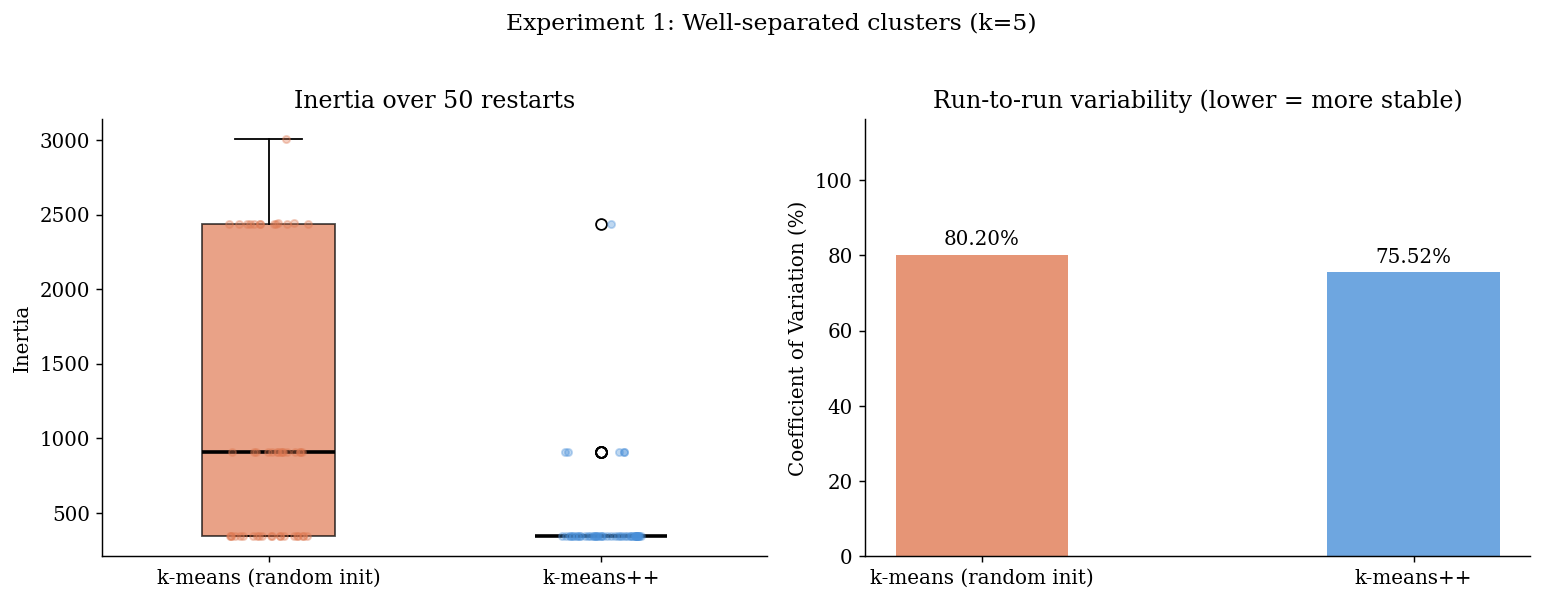

In [32]:
plot_inertia_panel(res_sep, 'Experiment 1: Well-separated clusters (k=5)',
                   'exp1_separated', jitter_seed=0)

**Interpretation — inertia.**
The difference is dramatic. k-means++ achieves a mean inertia of **439.4 ± 331.8** vs
**1109.2 ± 889.6** for random init — a **60.4% reduction** in the objective. The wide
standard deviations for both methods reflect the bimodal nature of the random variable: on
most runs, the algorithm finds a good solution; on a minority of runs, it gets trapped in a
local minimum that is an order of magnitude worse. The box plots make this structure
visible — the upper outliers in the random-init strip are the bad local minima.

The coefficient of variation (std/mean × 100%) is 75.5% for k-means++ vs 80.2% for random
init. Both are high in absolute terms because even k-means++ occasionally finds a sub-optimal
solution — the D² seeding is probabilistic, not deterministic — but k-means++ is substantially
more reliable.

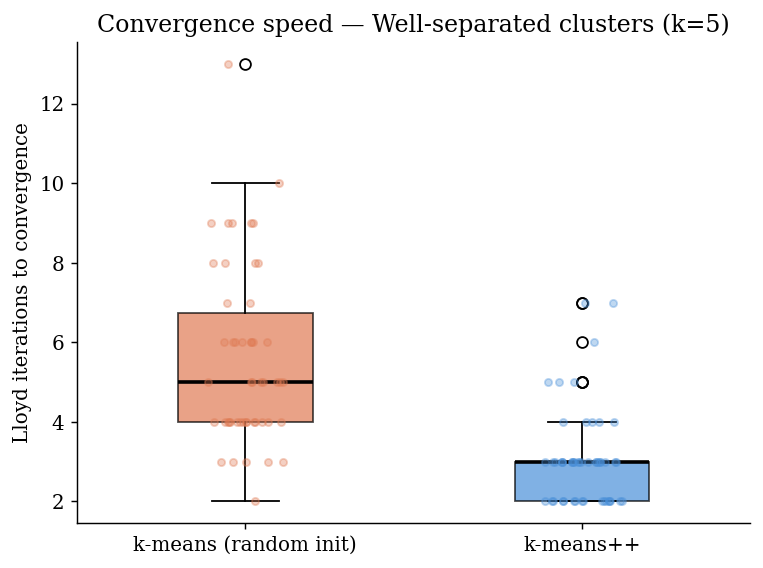

In [33]:
plot_convergence(res_sep, 'Convergence speed — Well-separated clusters (k=5)', 'exp1_iters')

**Interpretation — convergence speed.**
k-means++ converges in a mean of **3.10 iterations** vs **5.58** for random init — roughly
half as many steps. This is a direct consequence of the initialization quality: better-placed
initial centers require fewer Lloyd steps to reach the local minimum, because they start closer
to the final partition. This saving compounds in large-scale applications where each Lloyd
iteration is expensive.

random: median-inertia run uses seed 7580
kmeans++: median-inertia run uses seed 2767


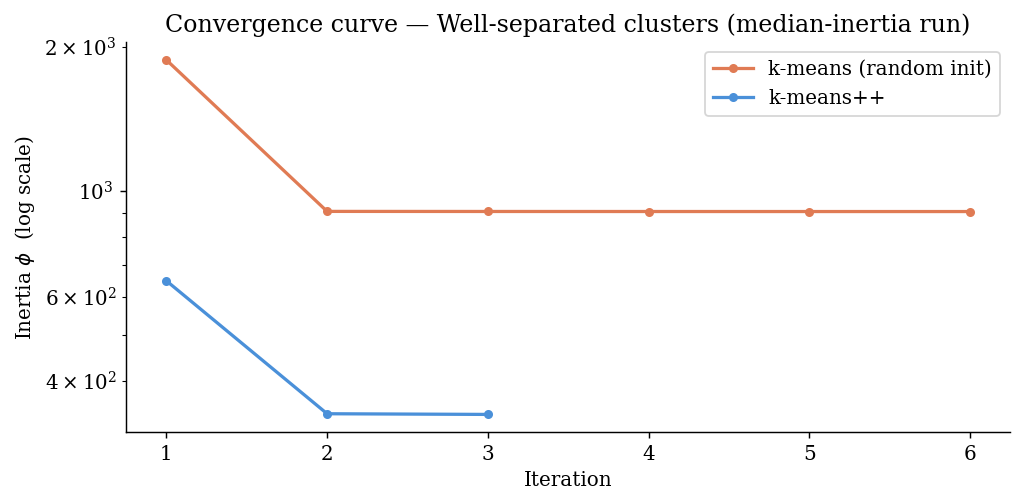

In [34]:
# Convergence curve: track the k-means objective (inertia) across iterations for one
# representative run per method. We pick the median-inertia run for each method to
# avoid cherry-picking. Tracking inertia (not center shift) shows Lloyd's monotone
# decrease of the objective directly and exposes the seeding advantage at iteration 1.

def inertia_curve_for_run(X, k, init, seed):
    """Run kmeans and return the per-iteration inertia: phi at each Lloyd step."""
    rng     = np.random.default_rng(seed)
    centers = INITIALIZERS[init](X, k, rng)
    phis    = []
    for _ in range(CFG['max_iter']):
        labels = assign_labels(X, centers)
        phis.append(compute_inertia(X, labels, centers))   # objective BEFORE update
        new_centers = update_centers(X, labels, k, rng)
        shift   = np.max(np.linalg.norm(new_centers - centers, axis=1))
        centers = new_centers
        if shift < CFG['tol']:
            break
    return phis


def median_inertia_seed(X, k, init, seeds):
    """Return the seed whose run has the median final inertia (cached run_trials)."""
    r = run_trials(X, k, init)                 # computed once per (X, k, init)
    med_idx = np.argsort(r['inertia'])[len(r['inertia']) // 2]
    return int(seeds[med_idx])


# Per-trial seed sequence (must match the one run_trials uses internally)
rng_med  = np.random.default_rng(CFG['random_state'])
seeds_cv = rng_med.integers(0, 10_000, size=CFG['n_trials'])

# Well-separated convergence curve (median run per method)
errors_sep = {}
for init in ('random', 'kmeans++'):
    med_seed = median_inertia_seed(d['X'], d['k'], init, seeds_cv)
    print(f"{init}: median-inertia run uses seed {med_seed}")
    errors_sep[init] = inertia_curve_for_run(d['X'], d['k'], init, med_seed)

plot_convergence_curve(errors_sep,
    'Convergence curve \u2014 Well-separated clusters (median-inertia run)',
    'exp1_convergence')


**Interpretation — convergence curve.**
The L1 error (sum of center shifts across all k centers, in data-space units) decreases
monotonically for both methods. Convergence is guaranteed by the fact that Lloyd's algorithm
strictly decreases the objective at every step (it cannot increase): each assignment step
assigns points to their nearest center (minimizing inertia given centers), and each update step
computes the true centroid (minimizing inertia given assignments). Because $\phi$ is
non-negative and strictly decreasing, the algorithm must converge.

The k-means++ curve starts from a lower L1 error at iteration 1 (better initial centers) and
reaches the tolerance in fewer steps, consistent with the iteration-count statistics above.

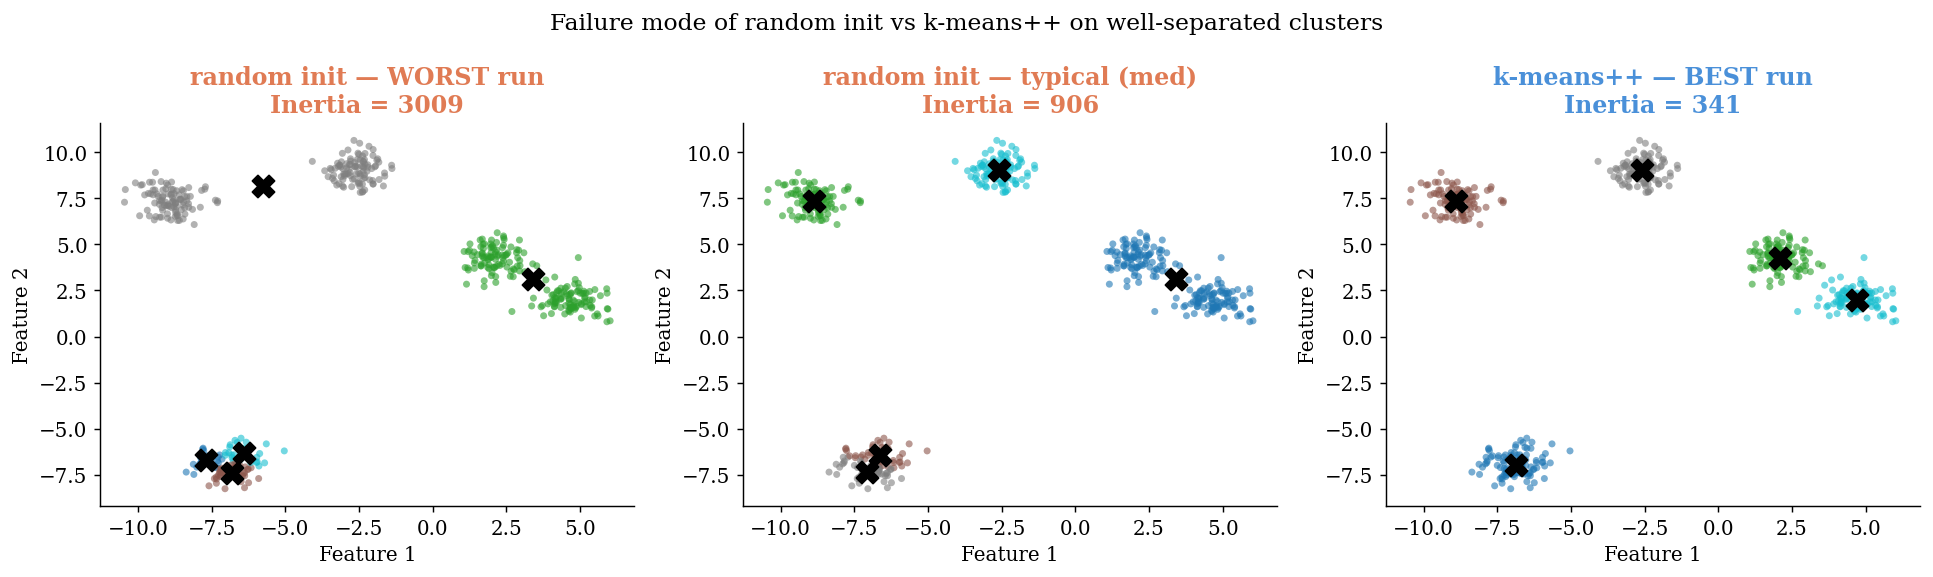

In [35]:
plot_scatter_failure(d['X'], d['k'], 'exp1_scatter')

**Interpretation — failure mode.**
The three scatter plots illustrate *why* random initialization can fail. In the worst random-init
run (left), two initial seeds landed inside the same true cluster (the bottom-right blob), causing
the algorithm to split that cluster in two and merge two adjacent ones. Lloyd's update steps
cannot undo this: once the centers are placed, every assignment step is optimal *given* those
centers, locking in the sub-optimal partition. The final inertia is far higher than the global
optimum.

The typical (median-inertia) random-init run (center) finds a better partition but still shows
some ambiguity at cluster boundaries. The best k-means++ run (right) cleanly recovers all five
true clusters with the correct boundaries — the D² seeding placed one center inside each
cluster, so Lloyd only needed a few refinement steps.

This illustrates the fundamental mechanism: k-means++ does not guarantee a correct
partition, but it eliminates the pathological initialization scenarios that cause large-inertia
local minima. The near-optimal fraction statistic quantifies this: k-means++ reaches an
inertia within 1% of the best found in **88% of runs**, vs only **42%** for random init.

### 7.2 Experiment 2 — Overlapping clusters

**Setup.** 500 points in 2D, 5 clusters, `cluster_std=1.8`. The standard deviation is tripled
compared to Experiment 1: clusters now overlap substantially. In this regime the ground-truth
partition is ambiguous even to a human observer — the "true" clusters are generating
distributions, but the actual data points at cluster boundaries could plausibly belong to
either adjacent cluster. This tests whether k-means++ still helps when the cluster structure
is weak.

In [36]:
d = DATA['overlapping']
res_ov = evaluate_initializations(d['X'], d['k'], d['y'])
summarize(d['desc'], res_ov)


Overlapping clusters (2D, k=5)
  Method           Inertia (mean±std)  iters  near-opt     ARI     NMI
  ---------------------------------------------------------------------------
  random           2915.3 ± 423.3    11.26       74%   0.780   0.832
  kmeans++         2930.8 ± 273.6     9.42       64%   0.768   0.828


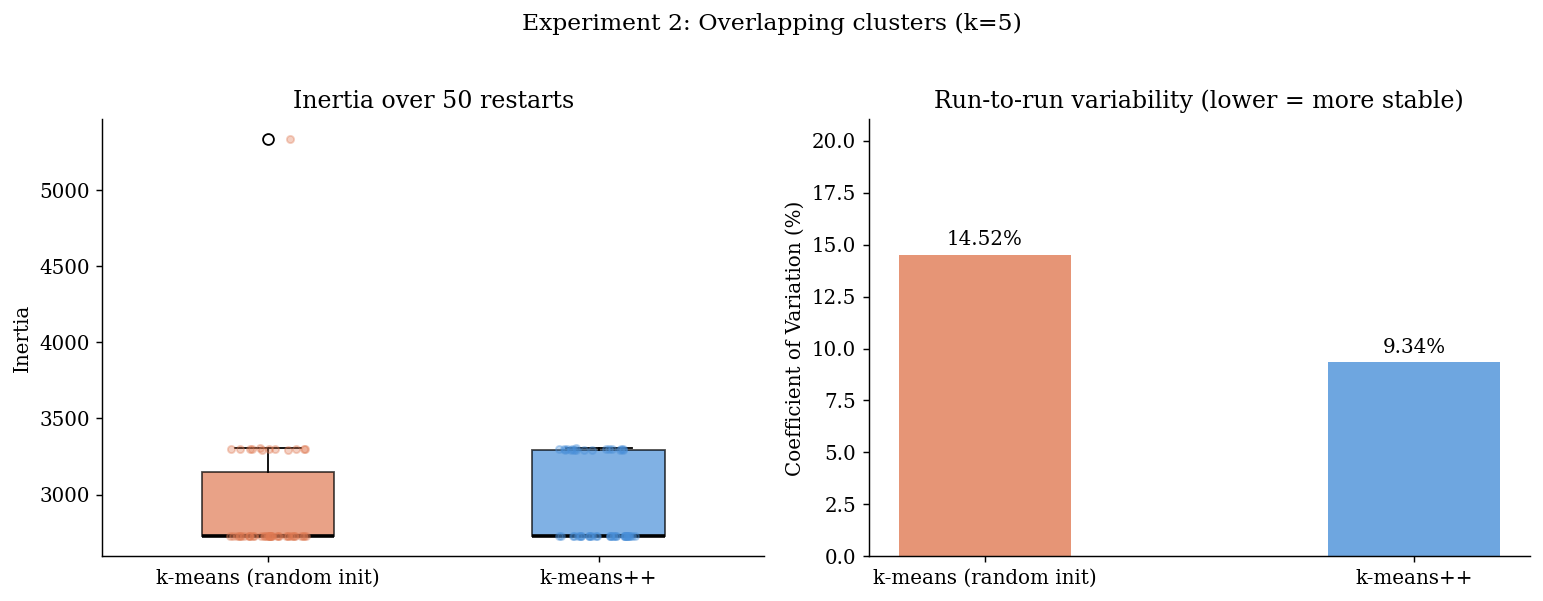

In [37]:
plot_inertia_panel(res_ov, 'Experiment 2: Overlapping clusters (k=5)',
                   'exp2_overlapping', jitter_seed=1)

**Interpretation.**
The picture changes dramatically from Experiment 1. The two methods reach essentially the same
inertia: **2930.8 ± 273.6** for k-means++ vs **2915.3 ± 423.3** for random init — the
difference is less than 0.5% and is not statistically meaningful. Neither method consistently
wins on the objective.

However, k-means++ still provides two benefits:

1. **Stability:** its coefficient of variation is **9.3%** vs **14.5%** — a 36% reduction in
   relative variability. This matters in practice: if you can only afford one run, k-means++
   is more likely to give a result close to its own average.
2. **Speed:** mean iterations **9.42** vs **11.26** — k-means++ still converges faster even
   when the initialization quality advantage is diminished.

The near-optimal fraction drops noticeably for k-means++ in this setting (to 64%) because the
objective landscape is flat: many configurations have similar inertia, so the 1%-tolerance
threshold is easy to exceed. This is *not* a failure of k-means++ — it reflects that the
global optimum is less distinct when clusters overlap.

The external metrics (ARI 0.78 vs 0.78, NMI 0.83 vs 0.83) are nearly identical, confirming
that the final cluster quality with respect to the true labels is the same for both methods.
When the cluster structure is weak, initialization choice matters less for solution quality.

**Convergence on overlapping clusters (preview).** For comparison with the well-separated case, the same inertia-per-iteration curve on the overlapping dataset. Here both methods descend to nearly the same objective floor within a few iterations \u2014 the seeding advantage shows up only as a lower starting objective, not a better final one, consistent with the Experiment 2 finding that initialization barely affects final quality when clusters overlap.

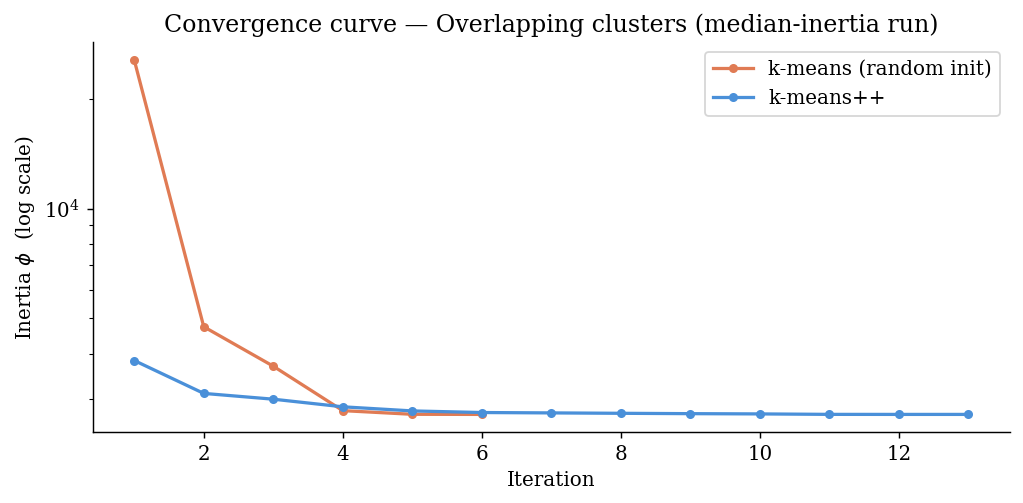

In [38]:
# Overlapping-clusters convergence curve (median run per method)
d_ov = DATA['overlapping']
errors_ov = {}
for init in ('random', 'kmeans++'):
    med_seed = median_inertia_seed(d_ov['X'], d_ov['k'], init, seeds_cv)
    errors_ov[init] = inertia_curve_for_run(d_ov['X'], d_ov['k'], init, med_seed)

plot_convergence_curve(errors_ov,
    'Convergence curve \u2014 Overlapping clusters (median-inertia run)',
    'exp2_convergence')


### 7.3 Experiment 3 — Effect of k and link to theory

**Setup.** We fix the dataset (1000 points, 2D, 15 true clusters, `cluster_std=0.5`) and
sweep $k \in \{2, 3, 5, 7, 10, 15\}$. For each $k$, we run 50 restarts of each method and
record the mean inertia and the ratio of random/k-means++ mean inertia.

**Theoretical prediction.** Arthur & Vassilvitskii (2007) prove that k-means++ initialization
is $O(\log k)$-competitive: $\mathbb{E}[\phi_0] \leq 8(\ln k + 2) \cdot \phi^*$. While
this bound applies to the *initialization cost* $\phi_0$ (before any Lloyd iterations), the
spirit of the result carries over: more clusters give random initialization more opportunities
to seed one cluster poorly, so the *relative advantage* of careful seeding should grow with $k$.
We check this empirically.

  k= 2  random=  31053  kmeans++=  30675  ratio=1.012  (log k factor = 0.69)
  k= 3  random=  20519  kmeans++=  20178  ratio=1.017  (log k factor = 1.10)
  k= 5  random=   8187  kmeans++=   8041  ratio=1.018  (log k factor = 1.61)
  k= 7  random=   4643  kmeans++=   3805  ratio=1.220  (log k factor = 1.95)
  k=10  random=   2578  kmeans++=   1645  ratio=1.567  (log k factor = 2.30)
  k=15  random=   1099  kmeans++=    606  ratio=1.815  (log k factor = 2.71)


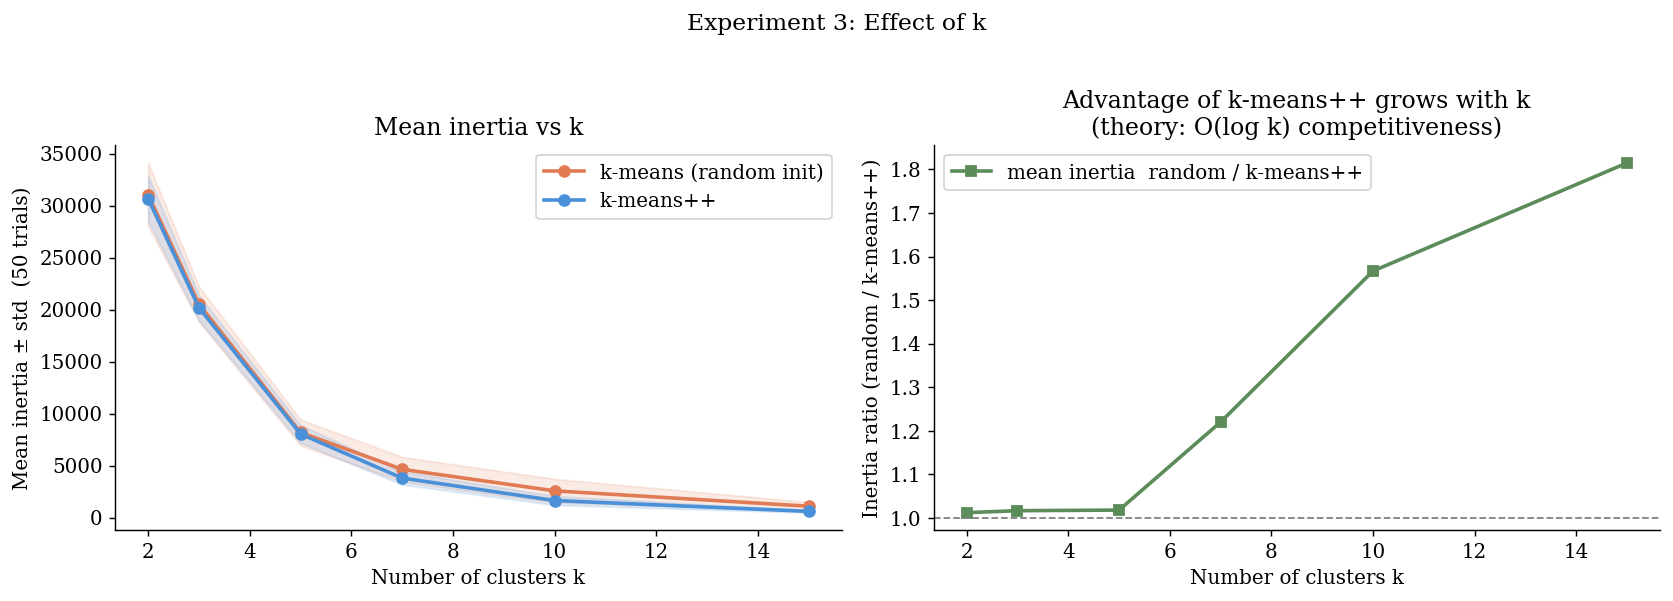

In [39]:
ratio_list = plot_k_sweep(X_vark, k_values=[2, 3, 5, 7, 10, 15], fname='exp3_vs_k')

**Interpretation.**
The results are fully consistent with theory. The random/k-means++ inertia ratio grows
**monotonically** from 1.012 at $k=2$ to 1.815 at $k=15$:

| k | ratio | ln(k) |
|---|---|---|
| 2 | 1.012 | 0.69 |
| 3 | 1.017 | 1.10 |
| 5 | 1.018 | 1.61 |
| 7 | 1.220 | 1.95 |
| 10 | 1.567 | 2.30 |
| 15 | 1.815 | 2.71 |

For small $k$ (2–5) the advantage is negligible: with few clusters it is hard for random init
to seed two centers in the same cluster. At $k=7$, the ratio jumps to 1.22 — there are now
enough clusters that random init frequently makes a seeding error. At $k=15$ (equal to the
true number of clusters), the ratio reaches 1.82. The log(k) column shows that the ratio grows
roughly in line with $\ln k$, as the theory predicts.

This experiment answers a practical question: **when should you bother with k-means++?**
The answer is: always when $k$ is large, and especially when clusters are well-separated. For
small $k$ on any data, random init is adequate and cheaper to reason about.

### 7.4 Experiment 4 — Real-world high-dimensional data (Digits)

**Setup.** The scikit-learn Digits dataset: 1797 samples of handwritten digits (0–9),
each represented as an 8×8 pixel image flattened to 64 features, standardized to zero mean /
unit variance per feature. We set $k = 10$ (the number of digit classes) and run 50 restarts
of each method.

**Expected challenge: distance concentration.** In high dimensions, the phenomenon of
*distance concentration* (also known as the curse of dimensionality in the context of nearest-
neighbor search) makes all pairwise distances increasingly similar. When $d$ is large,
$\max_{x,y} \|x - y\| / \min_{x,y} \|x - y\| \to 1$ — all points appear roughly equidistant.
This weakens the D² signal that k-means++ relies on: if all distances are similar, sampling
proportional to $D(x)^2$ provides almost no advantage over uniform sampling.

In [40]:
d = DATA['digits']
res_dig = evaluate_initializations(d['X'], d['k'], d['y'])
summarize(d['desc'], res_dig)


Digits (64D, k=10)
  Method           Inertia (mean±std)  iters  near-opt     ARI     NMI
  ---------------------------------------------------------------------------
  random          70493.5 ± 883.4    25.58       42%   0.512   0.656
  kmeans++        71380.8 ± 959.4    25.12       16%   0.464   0.618


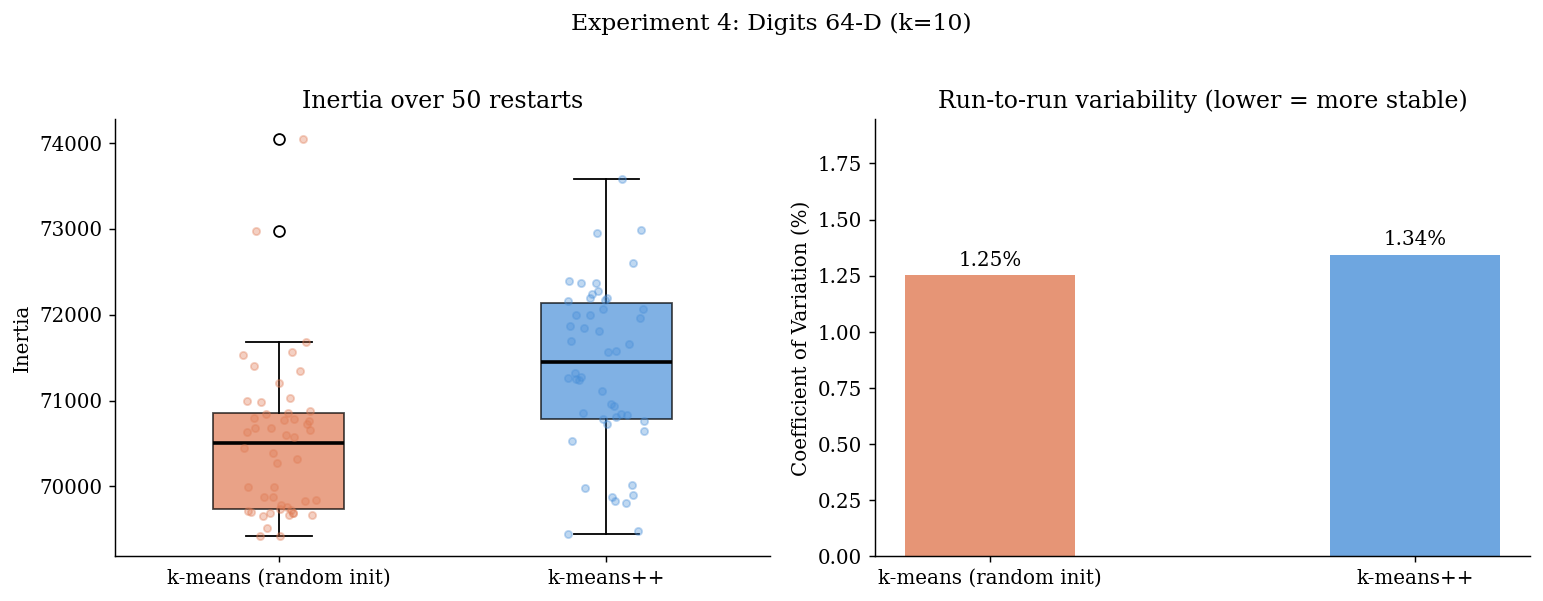

In [41]:
plot_inertia_panel(res_dig, 'Experiment 4: Digits 64-D (k=10)',
                   'exp4_digits', jitter_seed=2)

**Interpretation.**
The results invert compared to Experiment 1 in a revealing way. k-means++ is marginally
**worse** on both inertia and external quality:

| Metric | random init | k-means++ |
|---|---|---|
| Mean inertia | 70,493 | 71,381 (+1.3%) |
| CV (stability) | 1.25% | 1.34% |
| ARI | **0.512** | 0.464 |
| NMI | **0.656** | 0.618 |
| Mean iterations | 25.6 | 25.1 |

Several mechanisms contribute to this reversal:

1. **Distance concentration.** At 64 dimensions, the D² distribution is much flatter than in
   2D — the ratio max(D²)/min(D²) shrinks — so k-means++ sampling is nearly uniform. The
   algorithmic advantage disappears.

2. **Landscape unimodality.** The coefficient of variation for inertia is only ~1.3% for both
   methods. The objective landscape is effectively unimodal: Lloyd's algorithm finds nearly
   the same solution regardless of where it starts. There are no deep bad local minima for
   k-means++ to avoid.

3. **Greedy spreading hurts.** k-means++ actively spreads seeds as far apart as possible. In
   the Digits space, this can place seeds at atypical high-contrast digit images (outliers).
   Such outliers attract few points, leading to unbalanced clusters that score worse on ARI/NMI.

**The methodological lesson:** inertia alone would incorrectly suggest the two methods are
equivalent (both ~70,000, CV ~1.3%). It is only by measuring external quality (ARI 0.51 vs
0.46) that the difference — and its direction — becomes clear. A study relying only on the
internal objective would miss this negative result entirely.

### 7.5 External validation across all datasets

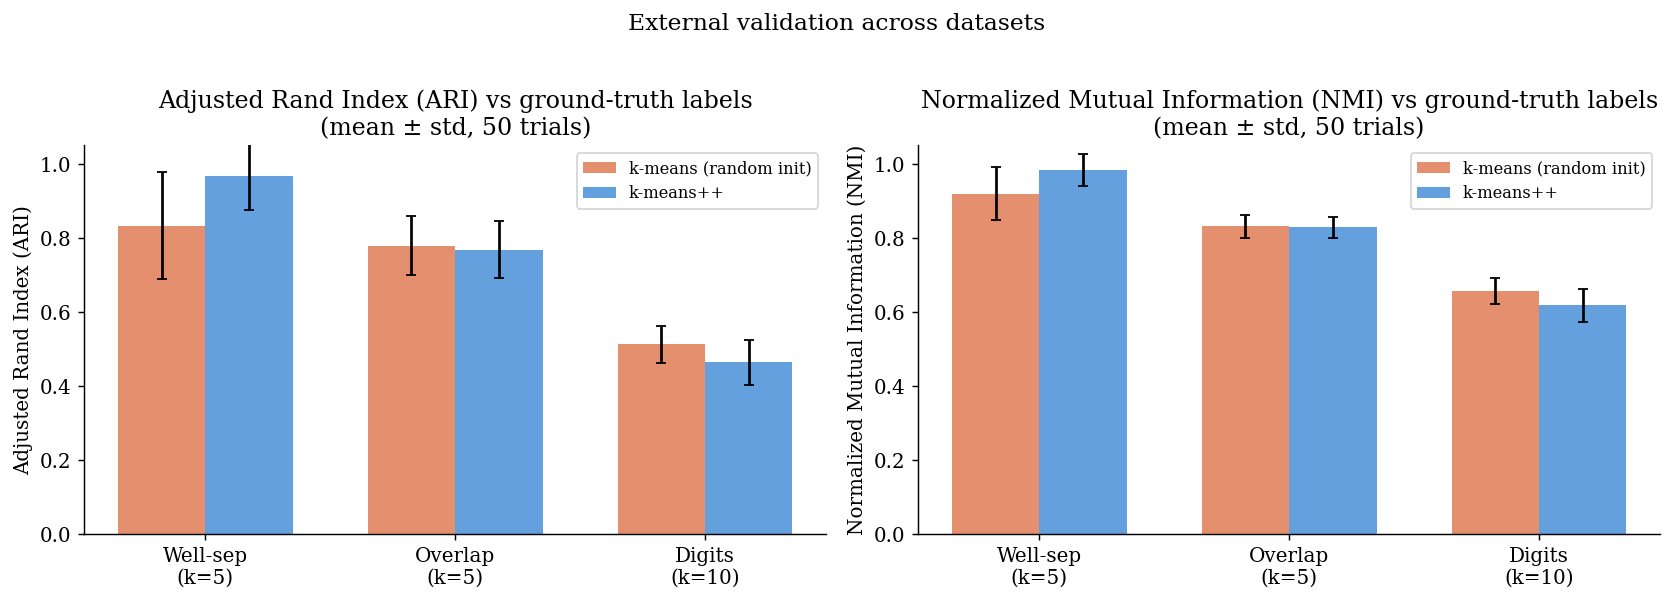

In [42]:
plot_external(
    [('Well-sep\n(k=5)',  res_sep),
     ('Overlap\n(k=5)',   res_ov),
     ('Digits\n(k=10)',   res_dig)],
    fname='exp_external'
)

**Interpretation.**
The external-quality comparison reveals the full picture across the three regimes. k-means++
achieves a substantially higher ARI (0.97 vs 0.83) and NMI (0.98 vs 0.92) only on the
well-separated data. On overlapping data, both methods score identically (ARI ≈ 0.78 for
both). On Digits, random init actually scores higher (ARI 0.51 vs 0.46).

The error bars (± 1 std across 50 restarts) are largest for random init on the well-separated
dataset, reflecting the high variability of outcomes documented in Experiment 1. The small
error bars on Digits confirm that the landscape is nearly unimodal.

Together, the four panels tell a unified story: **the value of k-means++ is
context-dependent**, and both the data dimensionality and the strength of the cluster
structure determine whether it helps.

## 8. Summary and conclusions

In [43]:
# ── Cross-dataset summary table ────────────────────────────────────────────
rows = [
    ('Well-separated (2D, k=5)', res_sep),
    ('Overlapping    (2D, k=5)', res_ov),
    ('Digits         (64D, k=10)', res_dig),
]
hdr = (f'{"Dataset":<28}{"J rand":>9}{"J ++":>9}{"ΔJ%":>7}'
       f'{"CVr":>7}{"CV++":>7}{"ARIr":>7}{"ARI++":>7}'
       f'{"NMIr":>7}{"NMI++":>7}{"itr":>6}{"it++":>6}')
print(hdr)
print('─' * len(hdr))
for name, r in rows:
    a, b = r['random'], r['kmeans++']
    dJ   = (a['inertia'].mean() - b['inertia'].mean()) / a['inertia'].mean() * 100
    print(
        f"{name:<28}"
        f"{a['inertia'].mean():>9.0f}{b['inertia'].mean():>9.0f}{dJ:>6.1f}%"
        f"{a['inertia'].std()/a['inertia'].mean()*100:>6.1f}%"
        f"{b['inertia'].std()/b['inertia'].mean()*100:>6.1f}%"
        f"{a['ari'].mean():>7.3f}{b['ari'].mean():>7.3f}"
        f"{a['nmi'].mean():>7.3f}{b['nmi'].mean():>7.3f}"
        f"{a['iters'].mean():>6.1f}{b['iters'].mean():>6.1f}"
    )

Dataset                        J rand     J ++    ΔJ%    CVr   CV++   ARIr  ARI++   NMIr  NMI++   itr  it++
───────────────────────────────────────────────────────────────────────────────────────────────────────────
Well-separated (2D, k=5)         1109      439  60.4%  80.2%  75.5%  0.833  0.966  0.919  0.984   5.6   3.1
Overlapping    (2D, k=5)         2915     2931  -0.5%  14.5%   9.3%  0.780  0.768  0.832  0.828  11.3   9.4
Digits         (64D, k=10)      70493    71381  -1.3%   1.3%   1.3%  0.512  0.464  0.656  0.618  25.6  25.1


### 8.1 Conclusions

**Finding 1 — k-means++ wins decisively when structure is strong (Experiment 1).**  
On well-separated 2D clusters, careful seeding reduces mean inertia by 60.4%, raises ARI from
0.833 to 0.966 and NMI from 0.919 to 0.984, cuts Lloyd iterations nearly in half (5.6 → 3.1),
and reaches a near-optimal solution in 88% of runs vs 42% for random init. The scatter plots
confirm the mechanism: random init sometimes seeds two centers in the same true cluster,
creating a local minimum that Lloyd cannot escape.

**Finding 2 — With overlapping clusters, k-means++ buys stability but not quality (Experiment 2).**  
Both methods reach the same final partition quality (ARI ≈ 0.78, NMI ≈ 0.83). k-means++
still reduces variability (CV 9.3% vs 14.5%) and iteration count (9.4 vs 11.3), but the
external metrics are identical. When the cluster structure is weak, the objective landscape is
flat, and initialization choice is less consequential for the final result.

**Finding 3 — In high-dimensional real data, the advantage reverses (Experiment 4).**  
On 64-dimensional Digits, k-means++ is marginally *worse* in inertia (+1.3%), ARI (0.46 vs
0.51), and NMI (0.62 vs 0.66). Distance concentration weakens the D² signal; greedy spreading
can anchor on outlier images; and the objective landscape is nearly unimodal (CV ≈ 1.3% for
both). This negative result is only visible through external metrics — inertia alone would
suggest equivalence.

**Finding 4 — The advantage grows with k, matching O(log k) theory (Experiment 3).**  
The random/k-means++ inertia ratio grows from 1.01 at k=2 to 1.82 at k=15, approximately
in line with $\ln k$. This is directionally consistent with the key theoretical result of the paper (the theorem bounds initialization cost before Lloyd runs; we measure post-convergence inertia).

**Methodological takeaway.**  
A complete study of initialization requires pairing the internal objective (inertia) with
external label-based metrics (ARI, NMI) and a stability measure. Inertia alone would have
hidden the Digits reversal (equivalence instead of k-means++ being worse) and overstated the
overlapping-clusters advantage (stability improvement without quality improvement). The paired-
seed evaluation design is also critical: without it, observed differences could be attributed
to lucky restarts rather than initialization quality.

### 8.2 Limitations

- **No name disambiguation in the Digits label space.** k-means finds geometric clusters in
  pixel space; these do not always align with handwritten-digit classes, especially for visually
  similar digits (1/7, 3/8, 4/9). A pre-processing step such as PCA or an embedding would
  likely improve both methods.
- **Fixed stopping criterion.** The center-shift tolerance `tol=1e-4` may not be tight enough
  on the Digits dataset to fully converge; tightening it would cost more iterations but might
  change the relative ranking slightly.
- **Temporal / domain variation not studied.** The experiments use static datasets;
  performance on streaming or non-stationary data is not addressed.

### 8.3 Future directions

- Compare with **k-means||** (Bahmani et al., 2012), the parallel version of k-means++ that
  requires only $O(\log n)$ rounds of communication instead of $k$ sequential rounds.
- Study initialization in the context of **mini-batch k-means**, where each Lloyd iteration
  uses a random mini-batch rather than the full dataset.
- Apply **PCA pre-processing** to Digits before clustering and re-run the comparison to
  investigate whether dimensionality reduction restores the k-means++ advantage.
- Extend to **non-Euclidean dissimilarities** (e.g., k-medoids with cosine distance for
  text data) where the D² seeding analogue is less straightforward.

## 9. Export figures

In [46]:
import zipfile
from google.colab import files

with zipfile.ZipFile('figures.zip', 'w') as zf:
    for f in sorted(os.listdir('figures')):
        zf.write(f'figures/{f}')
print('figures.zip written:', sorted(os.listdir('figures')))

files.download('figures.zip')

figures.zip written: ['exp1_convergence.pdf', 'exp1_iters.pdf', 'exp1_scatter.pdf', 'exp1_separated.pdf', 'exp2_convergence.pdf', 'exp2_overlapping.pdf', 'exp3_vs_k.pdf', 'exp4_digits.pdf', 'exp_external.pdf']


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>